<a href="https://colab.research.google.com/github/sereenajoshy/AI-ML-Intership/blob/main/DAY_4_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import zipfile
import os
import cv2

zip_path = "/content/animal_data.zip"
extract_path = "extracted_images"

# Extract the ZIP file
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

# Read all images
images = []

for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
            img_path = os.path.join(root, file)
            img = cv2.imread(img_path)

            if img is not None:
                images.append(img)

print("Total images loaded:", len(images))

Total images loaded: 1944


In [22]:
from PIL import Image, ImageEnhance, ImageOps
#PIL: Python Imaging Library (via Pillow), used for image processing.
#Image: Handles image loading, saving, and manipulation.
#ImageEnhance: Provides tools for enhancing image properties like brightness and contrast.
#ImageOps: Contains image processing utilities, such as flipping and grayscaling.
#os: A module to handle file system operations like creating directories and file paths.

import os

# Load the uploaded image
image_path = "/content/extracted_images/animal_data/Cow/Cow_10_1.jpg"  # Replace with your image file path
image = Image.open(image_path)

# Create a directory for augmented images
augmented_dir = "augmented_images"
#Creates the directory augmented_images
os.makedirs(augmented_dir, exist_ok=True)
 #Ensures no error is raised if the directory already exists.

# Augmentation functions
def augment_image(image, output_dir):
    # 1. Horizontal Flip
    # Flips the image horizontally (mirroring).
    flipped = ImageOps.mirror(image)
    #Saves the flipped image as flipped.jpeg in the output_dir
    flipped.save(os.path.join(output_dir, "flipped.jpeg"))

    # 2. Rotate
    rotated = image.rotate(30)
    #Rotates the image by 30 degrees (counterclockwise by default)
    rotated.save(os.path.join(output_dir, "rotated.jpeg"))

    # 3. Brightness Adjustment
    enhancer = ImageEnhance.Brightness(image)
    #Adjusts brightness by a factor of 1.5 (1.0 = original brightness).
    brighter = enhancer.enhance(1.5)
    brighter.save(os.path.join(output_dir, "brighter.jpeg"))

    # 4. Contrast Adjustment
    contrast = ImageEnhance.Contrast(image).enhance(2.0)
    #Doubles the image's contrast (2.0 = twice the original contrast).

    contrast.save(os.path.join(output_dir, "contrast.jpeg"))

    # 5. Grayscale
    grayscale = ImageOps.grayscale(image)
    grayscale.save(os.path.join(output_dir, "grayscale.jpeg"))

# Apply augmentations
augment_image(image, augmented_dir)
#Calls the augment_image function to apply all augmentations on the loaded image and save the results in the augmented_images directory.

# List the augmented files
print("Augmented images saved in:", augmented_dir)
print("Generated files:", os.listdir(augmented_dir))

Augmented images saved in: augmented_images
Generated files: ['contrast.jpeg', 'flipped.jpeg', 'brighter.jpeg', 'grayscale.jpeg', 'rotated.jpeg']


contrast.jpeg


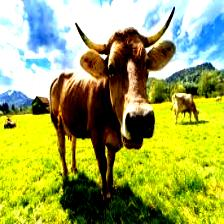

flipped.jpeg


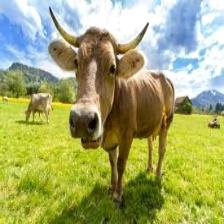

brighter.jpeg


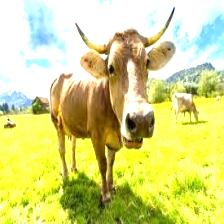

grayscale.jpeg


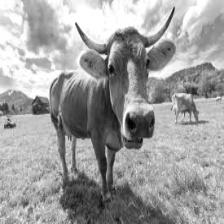

rotated.jpeg


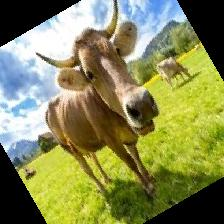

In [23]:
from IPython.display import display
from PIL import Image
import os

for filename in os.listdir(augmented_dir):
    image_path = os.path.join(augmented_dir, filename)

    print(filename)

    img = Image.open(image_path)
    display(img)

In [24]:
#og image pixel info
import numpy as np
image_array=np.array(image)/255.0
image_array

array([[[1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ],
        [0.99607843, 0.99607843, 0.98823529],
        ...,
        [0.65098039, 0.78823529, 0.94509804],
        [0.66666667, 0.79215686, 0.94117647],
        [0.66666667, 0.79607843, 0.93333333]],

       [[1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ],
        [1.        , 1.        , 0.99215686],
        ...,
        [0.65490196, 0.78431373, 0.94509804],
        [0.66666667, 0.79215686, 0.94117647],
        [0.67058824, 0.8       , 0.9372549 ]],

       [[0.99607843, 0.99215686, 1.        ],
        [1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ],
        ...,
        [0.65490196, 0.78431373, 0.94509804],
        [0.66666667, 0.79215686, 0.94117647],
        [0.67058824, 0.8       , 0.9372549 ]],

       ...,

       [[0.67843137, 0.70980392, 0.23529412],
        [0.80392157, 0.83921569, 0.34901961],
        [0.7372549 , 0

In [25]:
#flipped image pixel info
from PIL import Image
import os
import numpy as np

image = Image.open(os.path.join(augmented_dir, "flipped.jpeg"))

image_array = np.array(image) / 255.0
image_array

array([[[0.64705882, 0.8       , 0.96862745],
        [0.64705882, 0.8       , 0.96862745],
        [0.63921569, 0.79215686, 0.96078431],
        ...,
        [0.99607843, 1.        , 1.        ],
        [0.98431373, 1.        , 1.        ],
        [0.97647059, 0.99215686, 1.        ]],

       [[0.65098039, 0.79607843, 0.96862745],
        [0.64705882, 0.79215686, 0.95686275],
        [0.64313725, 0.78823529, 0.96078431],
        ...,
        [0.99607843, 1.        , 1.        ],
        [0.99607843, 1.        , 1.        ],
        [0.98431373, 1.        , 1.        ]],

       [[0.65490196, 0.79215686, 0.95686275],
        [0.65098039, 0.78823529, 0.94509804],
        [0.64313725, 0.78039216, 0.94509804],
        ...,
        [0.99607843, 1.        , 1.        ],
        [0.99607843, 1.        , 1.        ],
        [0.99607843, 1.        , 1.        ]],

       ...,

       [[0.85098039, 0.89019608, 0.2745098 ],
        [0.82352941, 0.85882353, 0.25098039],
        [0.81568627, 0